In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

from itertools import product, starmap
from scipy.optimize import minimize
import pandas as pd
import numpy as np
import io
import re
import zipfile
from curl_cffi import requests
import tidyfinance as tf
import openassetpricing as oap
import math
from ipca import InstrumentedPCA
start_date = "1960-01-01"
end_date = "2024-12-31"
dataset = "F-F_Research_Data_Factors"
openap = oap.OpenAP()


In [3]:
df= openap.dl_all_signals('pandas')
df.head()
df_copy = df.copy()
df['yyyymm'] = pd.to_datetime(df['yyyymm'].astype(str), format='%Y%m', errors='coerce')
type(df.iloc[-1]['yyyymm'])
df['year'] = df['yyyymm'].dt.year
start_year = int(df['year'].min())
end_year = int(df['year'].max())
print(f"Data covers years {start_year} to {end_year}")
df = df[df['year'] >= 1971]
df.head()
df_copy = df.copy()
df.sort_values(by=['yyyymm', 'permno'], inplace=True)
df.head()

def preprocess_characteristics(
    df: pd.DataFrame,
    date_col: str = "yyyymm",
    id_col: str = "permno",
    exclude_cols: tuple = ("ret", "excess_ret", "year"),
    sign_map: dict | None = None, 
) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()
    predictor_cols = [
        c for c in out.columns
        if c not in {date_col, id_col, *exclude_cols}
        and pd.api.types.is_numeric_dtype(out[c])
    ]

    out[predictor_cols] = (
        out.groupby(date_col)[predictor_cols]
           .transform(lambda x: x.fillna(x.median()))
    )

    if sign_map is not None:
        for c, s in sign_map.items():
            if c in predictor_cols:
                out[c] = out[c] * float(s)

    out[predictor_cols] = (
        out.groupby(date_col)[predictor_cols]
           .transform(lambda x: x.rank(method="average", pct=True))
    )
    def zscore_cs(x):
        sd = x.std(ddof=0)
        return np.zeros(len(x), dtype=float) if (sd == 0 or np.isnan(sd)) else (x - x.mean()) / sd

    out[predictor_cols] = (
        out.groupby(date_col)[predictor_cols]
           .transform(zscore_cs)
    )
    return out, predictor_cols

df_proc, predictors = preprocess_characteristics(df, sign_map=None)
print(f"Processed data has {len(predictors)} predictors: {predictors}")
df_proc.head()
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done

Data is downloaded: 13 mins
Data covers years 1925 to 2026


/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local

Processed data has 212 predictors: ['AM', 'AOP', 'AbnormalAccruals', 'Accruals', 'AccrualsBM', 'Activism1', 'Activism2', 'AdExp', 'AgeIPO', 'AnalystRevision', 'AnalystValue', 'AnnouncementReturn', 'AssetGrowth', 'BM', 'BMdec', 'BPEBM', 'Beta', 'BetaFP', 'BetaLiquidityPS', 'BetaTailRisk', 'BidAskSpread', 'BookLeverage', 'BrandInvest', 'CBOperProf', 'CF', 'CPVolSpread', 'Cash', 'CashProd', 'ChAssetTurnover', 'ChEQ', 'ChForecastAccrual', 'ChInv', 'ChInvIA', 'ChNAnalyst', 'ChNNCOA', 'ChNWC', 'ChTax', 'ChangeInRecommendation', 'CitationsRD', 'CompEquIss', 'CompositeDebtIssuance', 'ConsRecomm', 'ConvDebt', 'CoskewACX', 'Coskewness', 'CredRatDG', 'CustomerMomentum', 'DebtIssuance', 'DelBreadth', 'DelCOA', 'DelCOL', 'DelDRC', 'DelEqu', 'DelFINL', 'DelLTI', 'DelNetFin', 'DivInit', 'DivOmit', 'DivSeason', 'DivYieldST', 'DolVol', 'DownRecomm', 'EBM', 'EP', 'EarnSupBig', 'EarningsConsistency', 'EarningsForecastDisparity', 'EarningsStreak', 'EarningsSurprise', 'EntMult', 'EquityDuration', 'ExchSwit

In [123]:
df_data_all = df_proc[df_proc['year'] >= 1980]
stocks = df_data_all['permno'].unique()
stocks = stocks[:80]
df_data_all_stocks = df_data_all[df_data_all['permno'].isin(stocks)]

In [124]:
import ipca as ipca
sigdoc = openap.dl_signal_doc('pandas')
import wrds
import pandas as pd

db = wrds.Connection()
crsp_ret = db.raw_sql("""
    SELECT permno,
           date,
           ret
    FROM crsp.msf
    WHERE date >= '1980-01-01'
""")
csp_data = crsp_ret[crsp_ret['permno'].isin(stocks)]
csp_data.head()

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


,permno,date,ret
921,10006,1980-01-31,0.211679
922,10006,1980-02-29,-0.058795
923,10006,1980-03-31,-0.172078
924,10006,1980-04-30,-0.027451
925,10006,1980-05-30,0.084677


In [125]:
csp_data['date'] = pd.to_datetime(csp_data['date'])
csp_data['yyyymm'] = csp_data['date'].dt.to_period('M').dt.to_timestamp()
csp_data.head()

/var/folders/nf/zfnfl40j2hb_zjsqj1rbjq140000gn/T/ipykernel_29497/3857180958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  csp_data['date'] = pd.to_datetime(csp_data['date'])
/var/folders/nf/zfnfl40j2hb_zjsqj1rbjq140000gn/T/ipykernel_29497/3857180958.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  csp_data['yyyymm'] = csp_data['date'].dt.to_period('M').dt.to_timestamp()


,permno,date,ret,yyyymm
921,10006,1980-01-31,0.211679,1980-01-01
922,10006,1980-02-29,-0.058795,1980-02-01
923,10006,1980-03-31,-0.172078,1980-03-01
924,10006,1980-04-30,-0.027451,1980-04-01
925,10006,1980-05-30,0.084677,1980-05-01


In [126]:
df_data_all = df_data_all_stocks.merge(csp_data[['permno', 'yyyymm', 'ret']], on=['permno', 'yyyymm'], how='inner')
df_data_all.rename(columns = {"ret" : "excess_ret"}, inplace = True)
df_data_all.head()

,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,Price,Size,STreversal,year,excess_ret
0,10006,1980-01-01,0.762331,0.0,-1.678923,-0.933605,-0.162685,0.0,0.0,-1.966144,...,0.0,1.667650,-1.436979,-0.913860,-1.503410,-1.506424,-1.327370,-1.153457,1980,0.211679
1,10057,1980-01-01,-0.966793,0.0,1.278391,-1.070462,-0.162685,0.0,0.0,0.000000,...,0.0,1.660704,-1.448907,-1.320343,-1.603589,-1.331747,-0.972027,-1.363601,1980,0.282297
2,10058,1980-01-01,0.000000,0.0,0.000000,0.000000,-0.162685,0.0,0.0,0.000000,...,0.0,0.000000,0.985467,0.869220,0.868943,1.454087,1.474708,0.767860,1980,0.0
3,10065,1980-01-01,0.000000,0.0,0.000000,0.000000,-0.162685,0.0,0.0,0.000000,...,0.0,0.000000,-0.961962,-0.550929,-0.869669,0.201012,-1.120698,-0.545040,1980,0.099216
4,10103,1980-01-01,1.111676,0.0,0.000000,0.000000,-0.162685,0.0,0.0,1.634154,...,0.0,1.708550,0.985467,0.869220,0.868943,1.586429,1.558710,-0.405278,1980,0.083333


In [127]:
target_col = "excess_ret"   # or "ret"
id_col = "permno"
time_col = "yyyymm"

char_cols = [
    c for c in df_data_all.columns
    if c not in [id_col, time_col, "ret", "excess_ret", "year"]
    and pd.api.types.is_numeric_dtype(df_data_all[c])
]


In [128]:
stds = df_data_all[char_cols].std()
stds.sort_values(ascending=False, inplace=True)
char_cols = stds[stds > 1e-6].index.tolist()
char_cols = char_cols[:20]
print(f"Using {len(char_cols)} characteristics as predictors: {char_cols}")

Using 20 characteristics as predictors: ['sinAlgo', 'MomSeason16YrPlus', 'MomOffSeason16YrPlus', 'FR', 'CredRatDG', 'OrderBacklogChg', 'MomSeason11YrPlus', 'OrderBacklog', 'MomVol', 'BrandInvest', 'PredictedFE', 'MomOffSeason11YrPlus', 'DelBreadth', 'RDcap', 'retConglomerate', 'DivOmit', 'PayoutYield', 'Mom6mJunk', 'OrgCap', 'IntanBM']


In [129]:
df_data_all = df_data_all[char_cols + ["excess_ret", "year","yyyymm", "permno"]]

In [130]:

df_data_all = df_data_all.sort_values([time_col, id_col])

df_data_all["t_idx"] = df_data_all[time_col].factorize(sort=True)[0]

X = df_data_all[char_cols].to_numpy()
y = df_data_all[target_col].to_numpy()
indices = df_data_all[[id_col, "t_idx"]].to_numpy()

In [118]:
print(X.shape, y.shape)

(9998, 212) (9998,)


In [ ]:
import os
import numpy as np
import pandas as pd
import contextlib
from ipca import InstrumentedPCA

# ============================================================
# 1) Start from raw df_data_all
# ============================================================
raw = df_data_all.copy()

id_col = "permno"
time_col = "yyyymm"
ret_col = "excess_ret"   # or "ret"

# Parse month
if not np.issubdtype(raw[time_col].dtype, np.datetime64):
    raw[time_col] = pd.to_datetime(raw[time_col].astype(str), format="%Y%m", errors="coerce")

raw = raw.dropna(subset=[id_col, time_col]).sort_values([id_col, time_col]).copy()

# Build t+1 target (no look-ahead)
raw["y_ipca"] = raw.groupby(id_col)[ret_col].shift(-1)

# Characteristics
exclude = {id_col, time_col, "ret", "excess_ret", "year", "y_ipca"}
char_cols = [c for c in raw.columns if c not in exclude and pd.api.types.is_numeric_dtype(raw[c])]

# Keep only needed columns and clean finite values
df = raw[[id_col, time_col, "y_ipca"] + char_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()



In [ ]:

# Global id/time integer maps (just for IPCA indices)
i_map = {v: k for k, v in enumerate(pd.Index(df[id_col].unique()))}
t_map = {v: k for k, v in enumerate(pd.Index(sorted(df[time_col].unique())))}
df["i_idx"] = df[id_col].map(i_map).astype(np.int64)
df["t_idx"] = df[time_col].map(t_map).astype(np.int64)

# ============================================================
# 2) Rolling / Expanding OOS backtest (NO normalization leakage)
# ============================================================
cutoff = pd.Timestamp("2015-12-31")
test_months = sorted(df.loc[df[time_col] > cutoff, time_col].unique())

n_factors = 3
iter_tol = 1e-4
max_iter = 5000

min_train_months = 120      # require at least 10 years monthly history
rolling_window = None       # None => expanding; set e.g. 120 for rolling 10-year window

sse_model, sse_bench = 0.0, 0.0
rows = []

for t in test_months:
    if rolling_window is None:
        train_start = df[time_col].min()
    else:
        train_start = t - pd.DateOffset(months=rolling_window)

    train_mask = (df[time_col] < t) & (df[time_col] >= train_start)
    test_mask = (df[time_col] == t)

    train_df = df.loc[train_mask].copy()
    test_df = df.loc[test_mask].copy()

    if train_df[time_col].nunique() < min_train_months or len(test_df) == 0:
        continue

    # Raw matrices
    Xtr_raw = train_df[char_cols].to_numpy(np.float64)
    Xte_raw = test_df[char_cols].to_numpy(np.float64)
    ytr = train_df["y_ipca"].to_numpy(np.float64)
    yte = test_df["y_ipca"].to_numpy(np.float64)

    # ---- NO LEAKAGE normalization ----
    # Fit transform params ONLY on training data
    mu = np.nanmean(Xtr_raw, axis=0)
    sd = np.nanstd(Xtr_raw, axis=0)
    sd[sd < 1e-8] = 1.0

    Xtr = (Xtr_raw - mu) / sd
    Xte = (Xte_raw - mu) / sd

    # Optional robust clipping using train quantiles only
    q_lo = np.nanpercentile(Xtr, 1, axis=0)
    q_hi = np.nanpercentile(Xtr, 99, axis=0)
    Xtr = np.clip(Xtr, q_lo, q_hi)
    Xte = np.clip(Xte, q_lo, q_hi)

    idx_tr = train_df[["i_idx", "t_idx"]].to_numpy(np.int64)
    idx_te = test_df[["i_idx", "t_idx"]].to_numpy(np.int64)

    mtr = np.isfinite(Xtr).all(axis=1) & np.isfinite(ytr)
    mte = np.isfinite(Xte).all(axis=1) & np.isfinite(yte)

    Xtr, ytr, idx_tr = Xtr[mtr], ytr[mtr], idx_tr[mtr]
    Xte, yte, idx_te = Xte[mte], yte[mte], idx_te[mte]

    if len(ytr) == 0 or len(yte) == 0:
        continue

    mod = InstrumentedPCA(
        n_factors=n_factors,
        intercept=False,
        max_iter=max_iter,
        iter_tol=iter_tol
    )

    # Silence fit progress bar
    with open(os.devnull, "w") as fnull, contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
        mod.fit(Xtr, ytr, indices=idx_tr, data_type="panel")

    # Unseen month => mean_factor=True
    yhat = mod.predict(X=Xte, indices=idx_te, data_type="panel", mean_factor=True)

    # OOS benchmark = training-mean return
    ybar = ytr.mean()
    sse_model += np.sum((yte - yhat) ** 2)
    sse_bench += np.sum((yte - ybar) ** 2)

    rows.append({
        "month": t,
        "n_train": len(ytr),
        "n_test": len(yte),
        "mse_model": float(np.mean((yte - yhat) ** 2)),
        "mse_bench": float(np.mean((yte - ybar) ** 2)),
    })

# ============================================================
# 3) Results
# ============================================================
res = pd.DataFrame(rows).sort_values("month").reset_index(drop=True)
oos_r2 = 1.0 - sse_model / sse_bench if sse_bench > 0 else np.nan

print(f"OOS R^2 (> {cutoff.date()}): {oos_r2:.4f}")
print(f"Months evaluated: {len(res)}")
display(res.tail(12))


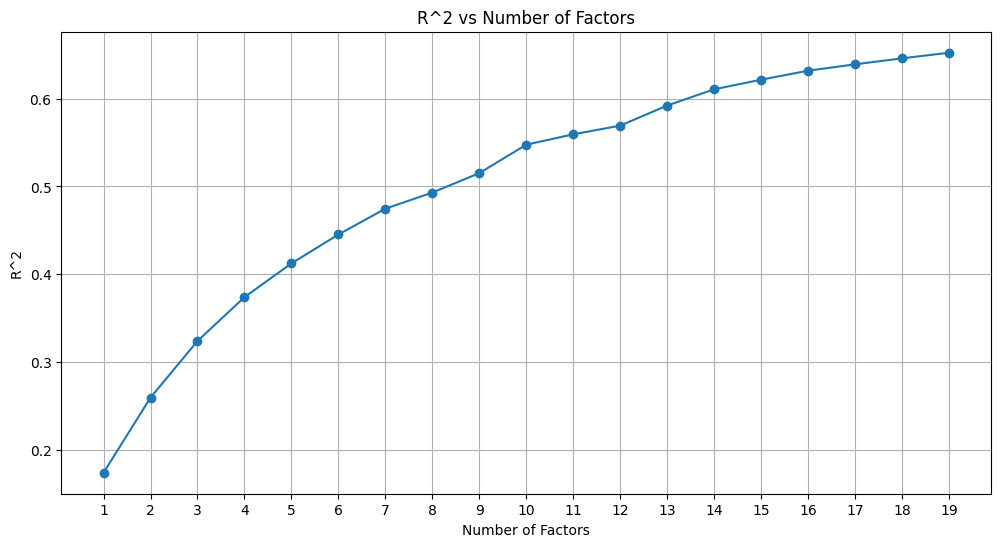

In [168]:
plt.plot(list(data.keys()), list(data.values()), marker='o')
plt.title("R^2 vs Number of Factors")
plt.xlabel("Number of Factors")
plt.ylabel("R^2")
plt.xticks(range(1, 20))
plt.grid()
plt.show()

In [186]:
test_months = sorted(df.loc[df[time_col] > cutoff, time_col].unique())

In [196]:
df[time_col].sort_values().unique()

<DatetimeArray>
['1980-01-01 00:00:00', '1980-02-01 00:00:00', '1980-03-01 00:00:00',
 '1980-04-01 00:00:00', '1980-05-01 00:00:00', '1980-06-01 00:00:00',
 '1980-07-01 00:00:00', '1980-08-01 00:00:00', '1980-09-01 00:00:00',
 '1980-10-01 00:00:00',
 ...
 '2024-02-01 00:00:00', '2024-03-01 00:00:00', '2024-04-01 00:00:00',
 '2024-05-01 00:00:00', '2024-06-01 00:00:00', '2024-07-01 00:00:00',
 '2024-08-01 00:00:00', '2024-09-01 00:00:00', '2024-10-01 00:00:00',
 '2024-11-01 00:00:00']
Length: 539, dtype: datetime64[ns]

In [191]:
csp_data.tail()

,permno,date,ret,yyyymm
154978,11308,2024-08-30,0.085856,2024-08-01
154979,11308,2024-09-30,-0.001725,2024-09-01
154980,11308,2024-10-31,-0.09115,2024-10-01
154981,11308,2024-11-29,-0.011407,2024-11-01
154982,11308,2024-12-31,-0.028402,2024-12-01
